# WhatsApp Chat NLP Analysis

This notebook analyzes a WhatsApp group chat using a simple NLP workflow.

It finds:
- Who texts the most
- Who asks more questions
- Who sends links
- Word count per user
- Basic visualizations
- Word cloud


## 1. Install Requirements

Run this only once if the libraries are not installed.

In [2]:
pip install matplotlib

     ---------------------------------------- 8.2/8.2 MB 6.2 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 3.5 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 13.6 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB ? eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 10.5 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
pip install openpyxl

     -------------------------------------- 250.9/250.9 kB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install wordcloud

     -------------------------------------- 306.1/306.1 kB 6.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [6]:
import re
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud


## 3. Load WhatsApp ZIP File

Change the path below if your ZIP file is stored somewhere else.

In [7]:
zip_path = r"D:\workspace\SRH\Semester_2\NLP\WA\WhatsApp Chat - Data Science 2025 1.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    txt_files = [f for f in zip_ref.namelist() if f.lower().endswith(".txt")]

    if not txt_files:
        raise Exception("No .txt WhatsApp chat file found inside the ZIP.")

    txt_file = txt_files[0]
    print("Using file:", txt_file)

    with zip_ref.open(txt_file) as file:
        lines = file.read().decode("utf-8", errors="ignore").splitlines()

print("Total raw lines:", len(lines))


Using file: _chat.txt
Total raw lines: 458


## 4. Parse WhatsApp Messages

This parser supports your format like: `[09.10.25, 6:11:46 PM] Rituu: image omitted`

In [8]:
messages = []

for line in lines:
    # Remove invisible WhatsApp unicode characters
    line = line.replace("\u200e", "").replace("\u202f", " ").replace("\xa0", " ").strip()

    # Match format: [09.10.25, 6:11:46 PM] Sender: Message
    match = re.match(
        r"^\[?(\d{1,2}\.\d{1,2}\.\d{2,4}),\s(.+?)\]\s(.+?):\s(.*)",
        line
    )

    if match:
        date, time, sender, message = match.groups()
        messages.append([date, time, sender.strip(), message.strip()])
    else:
        # Multiline message continuation
        if messages:
            messages[-1][3] += " " + line

df = pd.DataFrame(messages, columns=["date", "time", "sender", "message"])

print("Total parsed messages:", len(df))
df.head()


Total parsed messages: 329


,date,time,sender,message
0,07.10.25,1:44:50 PM,Data Science 2025,Messages and calls are end-to-end encrypted. O...
1,07.10.25,1:44:50 PM,Georgios Terzidis SRH,Georgios Terzidis SRH created this group
2,09.10.25,12:44:59 PM,Data Science 2025,You joined using a group link.
3,09.10.25,12:45:28 PM,~ Arya,~ Arya joined using a group link.
4,09.10.25,12:45:41 PM,Rahul Srh,Rahul Srh joined using a group link.


## 5. Basic NLP Feature Engineering

In [9]:
df["is_question"] = df["message"].str.contains(r"\?", regex=True)
df["has_link"] = df["message"].str.contains(r"http|www", case=False, regex=True)
df["word_count"] = df["message"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["message"].apply(lambda x: len(str(x)))
df["has_media"] = df["message"].str.contains("image omitted|video omitted|audio omitted|sticker omitted|document omitted|media omitted", case=False, regex=True)

df.head()


,date,time,sender,message,is_question,has_link,word_count,char_count,has_media
0,07.10.25,1:44:50 PM,Data Science 2025,Messages and calls are end-to-end encrypted. O...,False,False,18,105,False
1,07.10.25,1:44:50 PM,Georgios Terzidis SRH,Georgios Terzidis SRH created this group,False,False,6,40,False
2,09.10.25,12:44:59 PM,Data Science 2025,You joined using a group link.,False,False,6,30,False
3,09.10.25,12:45:28 PM,~ Arya,~ Arya joined using a group link.,False,False,7,33,False
4,09.10.25,12:45:41 PM,Rahul Srh,Rahul Srh joined using a group link.,False,False,7,36,False


## 6. User-wise Summary

In [21]:
summary = df.groupby("sender").agg(
    total_messages=("message", "count"),
    questions=("is_question", "sum"),
    links=("has_link", "sum"),
    media=("has_media", "sum"),
    total_words=("word_count", "sum"),
    total_characters=("char_count", "sum")
).sort_values(by="total_messages", ascending=False)

summary["avg_words_per_message"] = (summary["total_words"] / summary["total_messages"]).round(2)

summary.head(10)


,total_messages,questions,links,media,total_words,total_characters,avg_words_per_message
sender,,,,,,,
Georgios Terzidis SRH,42,5,5,3,940,5950,22.38
~ Haaris K,34,4,3,7,468,2831,13.76
~ Mrt,34,2,5,5,702,4812,20.65
Namrata Srh,24,3,0,0,173,848,7.21
Rahul Srh,18,9,0,1,132,707,7.33
Sharvari,14,3,0,0,176,926,12.57
Vikrant SRH,13,4,1,3,126,733,9.69
~ Munib Ahmed,12,5,0,0,126,714,10.50
~ Yash,10,5,0,0,49,257,4.90


## 7. Visualization: Top Users by Messages

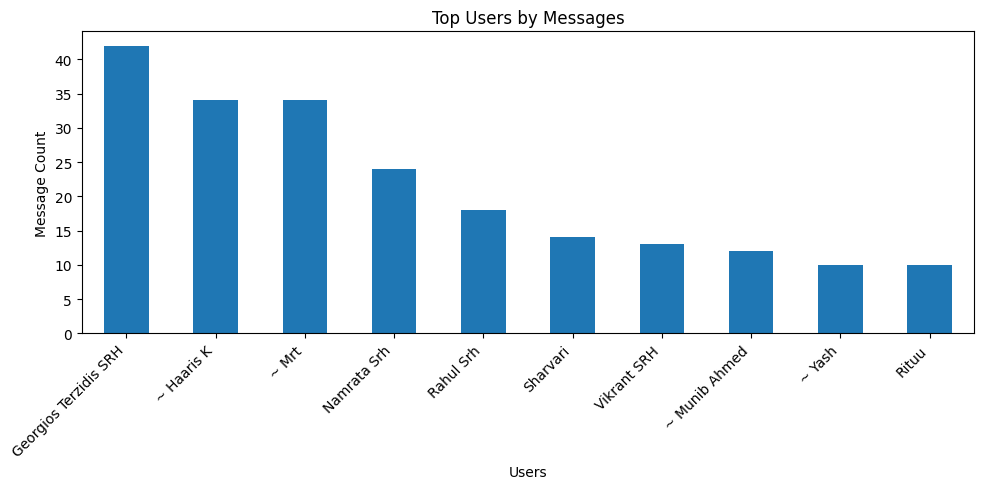

In [11]:
summary["total_messages"].head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Users by Messages")
plt.xlabel("Users")
plt.ylabel("Message Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Visualization: Users Asking Most Questions

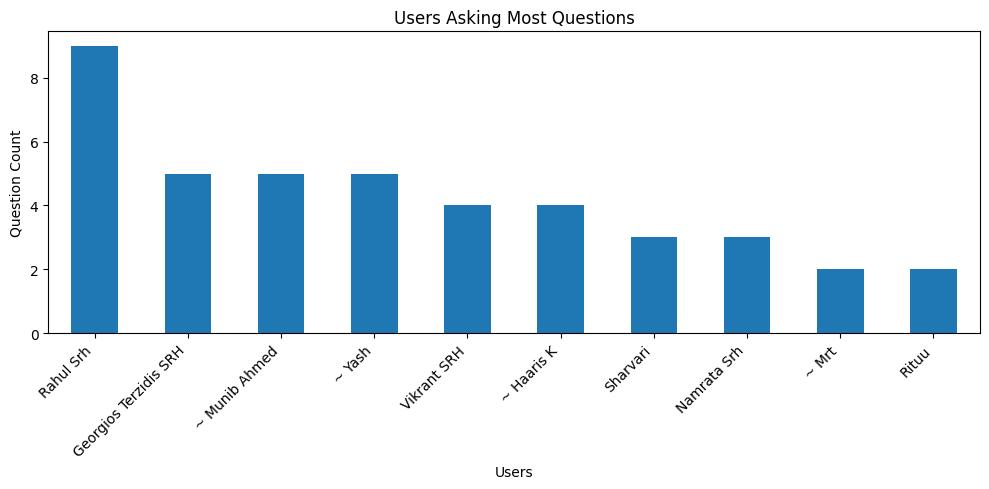

In [12]:
summary["questions"].sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.title("Users Asking Most Questions")
plt.xlabel("Users")
plt.ylabel("Question Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 9. Visualization: Users Sharing Most Links

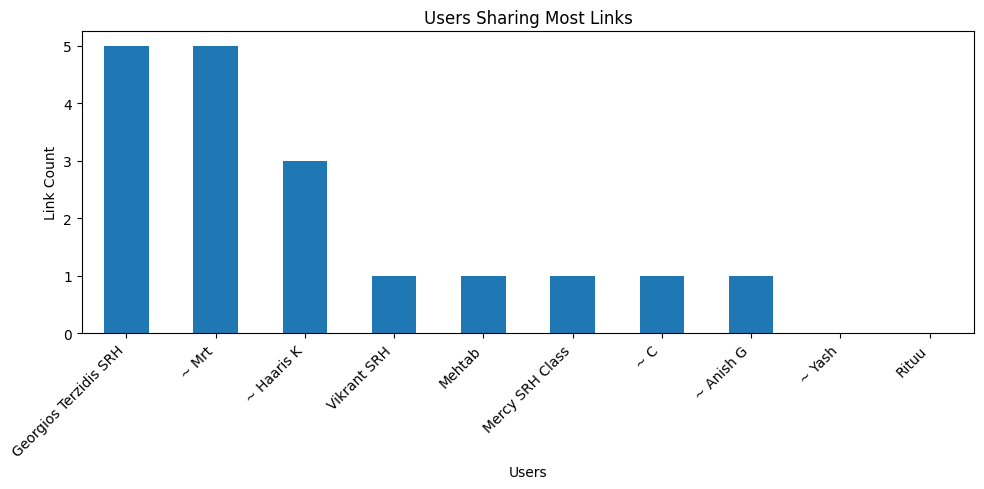

In [13]:
summary["links"].sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.title("Users Sharing Most Links")
plt.xlabel("Users")
plt.ylabel("Link Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Visualization: Media Messages

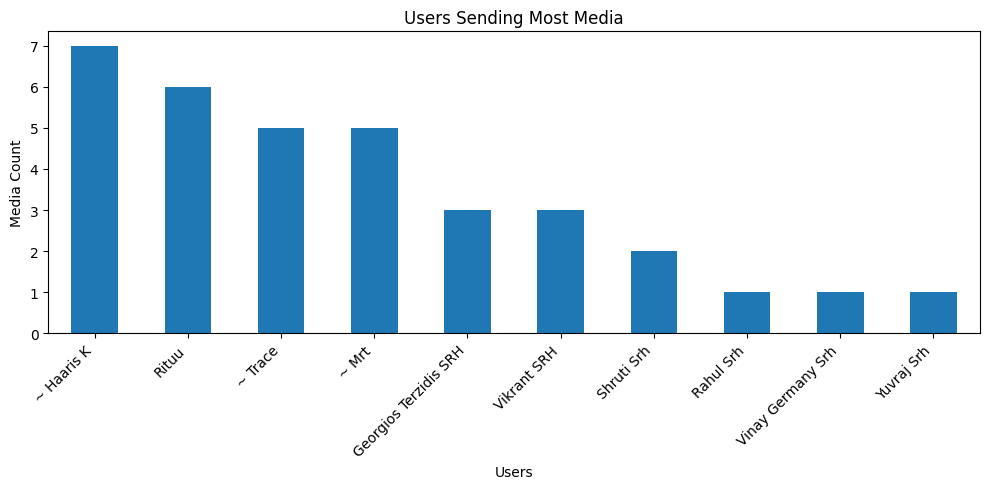

In [14]:
summary["media"].sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.title("Users Sending Most Media")
plt.xlabel("Users")
plt.ylabel("Media Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 11. Visualization: Top 5 User Contribution

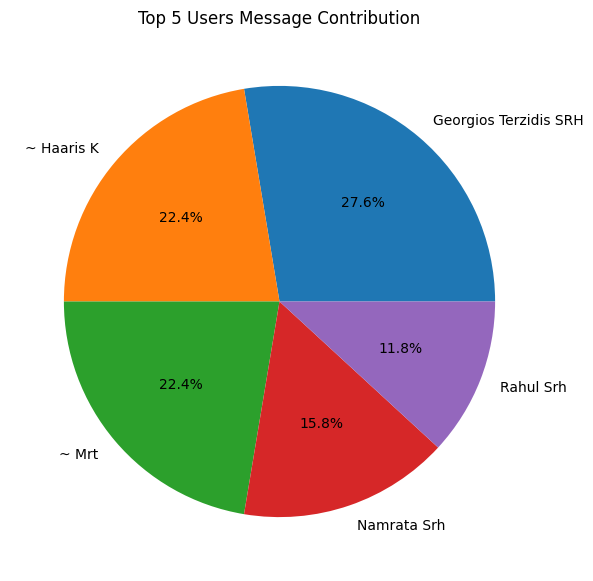

In [15]:
summary["total_messages"].head(5).plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))
plt.title("Top 5 Users Message Contribution")
plt.ylabel("")
plt.show()


## 12. Word Cloud

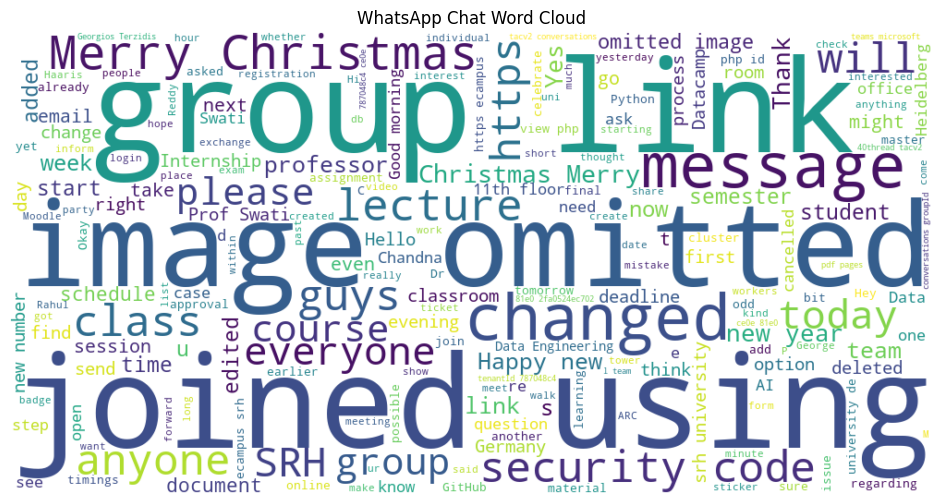

In [16]:
text = " ".join(df["message"].astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WhatsApp Chat Word Cloud")
plt.show()


## 13. Save Output to Excel

In [19]:
output_file = "whatsapp_nlp_summary.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Parsed Messages", index=False)
    summary.to_excel(writer, sheet_name="User Summary")

print("Excel file saved:", output_file)


Excel file saved: whatsapp_nlp_summary.xlsx


## 14. Final Basic Insights

In [20]:
print("Total messages:", len(df))
print("Total users:", df["sender"].nunique())
print("Most active user:", summary.index[0])
print("Most questions asked by:", summary["questions"].idxmax())
print("Most links sent by:", summary["links"].idxmax())


Total messages: 329
Total users: 48
Most active user: Georgios Terzidis SRH
Most questions asked by: Rahul Srh
Most links sent by: Georgios Terzidis SRH
